# Window + filter model vs. data: end-to-end check

Synthetic Gaussian noise with a **known** PSD goes through the *real* pipeline:
`BaseProcessingStep.process` (highpass/lowpass `sosfiltfilt`, `resample_poly` downsampling, trim) and `pour` (windowed STFT).
The averaged periodogram is compared with the backend's model:
`XYZSensitivityBackend` window kernel + `_convolve_matrix_components`, times `get_total_response`, plus the downsampling alias terms from `get_alias_response` (`preprocess_kwargs["alias_correction"]`, on by default).

The likelihood (`PSD.cu`, `-0.5 * 4 df Q - log det`) implies `E[2 df |X|^2] = C_model`, so **ratio = 1** means data and model agree.
Settings mirror `mojito_input/psd_multigpu_settings.py`. CPU only.

In [1]:
import types
import numpy as np
import matplotlib.pyplot as plt
from lisatools.globalfit.preprocessing import BaseProcessingStep
from lisatools.domains import STFTSettings
from lisatools.sensitivity import XYZSensitivityBackend as Backend
from lisatools.utils.utility import windowfun

# --- mirror psd_multigpu_settings.py ---
fs_orig = 0.4                 # mojito_lite L1 sampling (2.5 s)
dt, big_dt = 5.0, 86400.0     # downsampled cadence, STFT segment length
fmin, fmax = 1e-4, 1e-1
taper = 1 / fmin              # window_taper_duration
trim_days = 0.02 * 731        # 2% of the 731-day file, from each end
preprocess_kwargs = dict(
    highpass_kwargs=dict(cutoff=5e-6, order=2, zero_phase=True),
    lowpass_kwargs=dict(cutoff=0.16, order=2, zero_phase=True), # 0.101
    downsample_kwargs=dict(target_fs=1 / dt, window=("kaiser", 5.0)),
    # fixed duration instead of 2% so the synthetic series is trimmed like the real file
    trim_kwargs=dict(duration=trim_days * 86400, is_percent=False, trimming_type="from_each_end"),
)

n_days = 2 * trim_days + 50   # ~50 usable one-day segments after trimming
seed = 1

## True PSD and synthetic data
Analytic TDI2-X-like shape (steep, with the 0.06 Hz notch), defined up to the original Nyquist (0.2 Hz). Three channels are three independent realizations.

In [2]:
def S_true(f):
    f = np.maximum(f, 1e-6)
    c, L = 299792458.0, 2.5e9
    x = 2 * np.pi * f * L / c
    Sa = (3e-15) ** 2 * (1 + (4e-4 / f) ** 2) * (1 + (f / 8e-3) ** 4) / (2 * np.pi * f * c) ** 2
    So = (15e-12) ** 2 * (2 * np.pi * f / c) ** 2 * (1 + (2e-3 / f) ** 4)
    return 16 * np.sin(x) ** 2 * np.sin(2 * x) ** 2 * ((3 + np.cos(2 * x)) * Sa + So)

# frequency-domain synthesis: E|dt * rfft(x)|^2 = T S / 2
rng = np.random.default_rng(seed)
dt_orig = 1 / fs_orig
N = int(n_days * 86400 * fs_orig)
fk = np.fft.rfftfreq(N, dt_orig)
amp = np.sqrt(N * S_true(fk) / (4 * dt_orig))
amp[0] = 0.0
data = np.fft.irfft(amp * (rng.standard_normal((3, fk.size)) + 1j * rng.standard_normal((3, fk.size))), n=N, axis=-1)

## Data side: real preprocessing + `pour` STFT

In [3]:
def periodogram(data, steps):
    """Run the chosen preprocessing steps, STFT with the run's window; return (f, 2 df <|X|^2>, n_avg, proc, settings, window)."""
    proc = BaseProcessingStep(times=np.arange(data.shape[-1]) * dt_orig, data=data.copy(), fs=fs_orig, verbose=False, do_plots=False)
    times, _ = proc.process(**{k: preprocess_kwargs[k] for k in steps})
    st = STFTSettings.make_factory(big_dt=big_dt, min_freq=fmin, max_freq=fmax)(times, proc.dt, "cpu")
    nperseg = st.get_nperseg(proc.dt)
    w, _ = windowfun("tukey", nperseg, alpha=taper / (nperseg * proc.dt))   # as in engine.py
    X = np.asarray(proc.pour(settings=st, window=w).arr)                      # (channels, NT, NF_active)
    P = 2 * st.df * np.mean(np.abs(X) ** 2, axis=(0, 1))
    return np.asarray(st.f_arr), P, X.shape[0] * X.shape[1], proc, st, w

f, P, n_avg, proc, st, w = periodogram(data, list(preprocess_kwargs))
print(st, f"\naveraged periodograms per bin: {n_avg}")

STFTSettings(t0=1263165.0, dt=86400.0, df=1.1574074074074073e-05, NT=50, NF=8641, min_freq=0.00010416666666666666, max_freq=0.09999999999999999, backend=cpu) 
averaged periodograms per bin: 150


## Model side: the backend's own window kernel and convolution

In [4]:
def backend_convolve(C, f, st, w):
    """Run XYZSensitivityBackend's window kernel + _convolve_matrix_components on a real PSD C(f)."""
    m = types.SimpleNamespace(xp=np, window_values=w, active_slice=st.active_slice, fft_batch_size=512,
                              basis_settings=types.SimpleNamespace(basis_shape_active=(1, f.size)))
    Backend.window_kernel.fset(m, Backend._get_window_kernel(m))
    c = np.asarray(C, dtype=float)[None]
    z = np.zeros_like(c, dtype=complex)
    return Backend._convolve_matrix_components(m, c, c, c, z, z, z)[0][0]

def with_aliases(proc, f):
    """S x filters plus the downsampling alias terms (BaseProcessingStep.get_alias_response),
    the same terms the engine hands to the C++ covariance. S_true is real, so the conjugation
    of the negative-frequency aliases does not matter here."""
    C = S_true(f) * proc.get_total_response(f)
    alias = proc.get_alias_response(f)
    if alias is not None:
        f_a, resp_a = alias
        C = C + np.sum(S_true(np.abs(f_a)) * resp_a, axis=0)
    return C

resp = proc.get_total_response(f)   # filters_response handed to the backend in engine.py
models = {
    "backend: conv(S x filters + aliases)": backend_convolve(with_aliases(proc, f), f, st, w),
    "backend: conv(S x filters)": backend_convolve(S_true(f) * resp, f, st, w),
    "no window conv: S x filters x mean(w^2)": S_true(f) * resp * np.mean(w ** 2),
    "no filters: conv(S)": backend_convolve(S_true(f), f, st, w),
}

## Ratio data / model
Binned means with the expected ±1σ scatter of the binned ratio (shaded, for the backend model). Bottom panel: zoom on the top of the band (log y), where downsampling aliasing would show up.

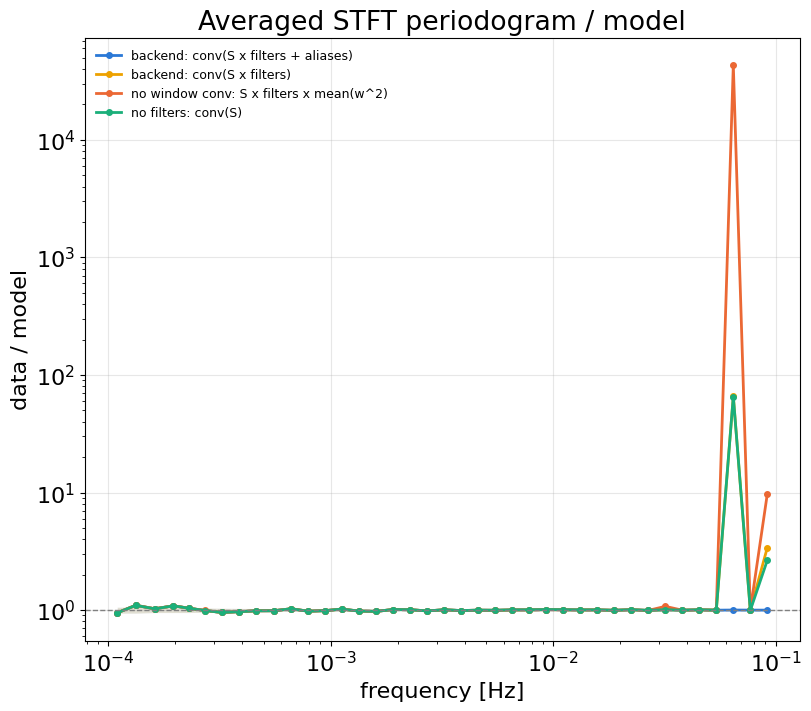

             band [Hz]    backend: conv(S x filters     backend: conv(S x filters)    no window conv: S x filter           no filters: conv(S)
  1.04e-04 -  1.94e-04                         1.034                         1.034                         1.036                         1.034
  1.94e-04 -  3.63e-04                         0.995                         0.995                         0.996                         0.995
  3.63e-04 -  6.78e-04                         0.996                         0.996                         0.996                         0.996
  6.78e-04 -  1.27e-03                         0.997                         0.997                         0.997                         0.997
  1.27e-03 -  2.36e-03                         0.994                         0.994                         0.995                         0.995
  2.36e-03 -  4.41e-03                         0.997                         0.997                         0.998                         0.998

In [5]:
def binned(f, r, edges):
    idx = np.digitize(f, edges) - 1
    ok = [i for i in range(len(edges) - 1) if np.any(idx == i)]
    fc = np.array([np.exp(np.mean(np.log(f[idx == i]))) for i in ok])
    mean = np.array([np.mean(r[idx == i]) for i in ok])
    sig = np.array([1 / np.sqrt(n_avg * np.sum(idx == i)) for i in ok])
    return fc, mean, sig

colors = ["#2a78d6", "#eda100", "#eb6834", "#1baf7a"]
fig, ax = plt.subplots(1, 1, figsize=(8, 7), constrained_layout=True)
for (name, M), col in zip(models.items(), colors):
    fc, r, s = binned(f, P / M, np.geomspace(f[0], f[-1], 40))
    ax.loglog(fc, r, "-o", color=col, lw=2, ms=4, label=name)
    fl, rl, sl = binned(f, P / M, np.linspace(0.03, f[-1], 40))
    if name.startswith("backend"):
        ax.fill_between(fc, 1 - s, 1 + s, color=col, alpha=0.15, lw=0)

ax.axhline(1, color="0.5", lw=1, ls="--")
ax.set_ylabel("data / model")
ax.grid(alpha=0.3)
ax.set_title("Averaged STFT periodogram / model")
ax.legend(frameon=False, fontsize=9)
ax.set_xlabel("frequency [Hz]")
plt.show()

edges = np.geomspace(f[0], f[-1], 12)
print(f"{'band [Hz]':>22s}" + "".join(f"{k[:26]:>30s}" for k in models))
for a, b in zip(edges[:-1], edges[1:]):
    sel = (f >= a) & (f < b)
    print(f"{a:10.2e} - {b:9.2e}" + "".join(f"{np.mean(P[sel] / M[sel]):30.3f}" for M in models.values()))

## Same model with the code from 39b7076
Loads `_get_window_kernel`, the `window_kernel` setter and `_convolve_matrix_components` as they were in commit `39b70769` (two-sided complex FFT, before the rfft rewrite) and runs them on the same inputs. The ratio must coincide with the filters-only backend line above (39b7076 has no alias terms).

max per-bin |M_39b7076 / M_current - 1| = 2.99e-06


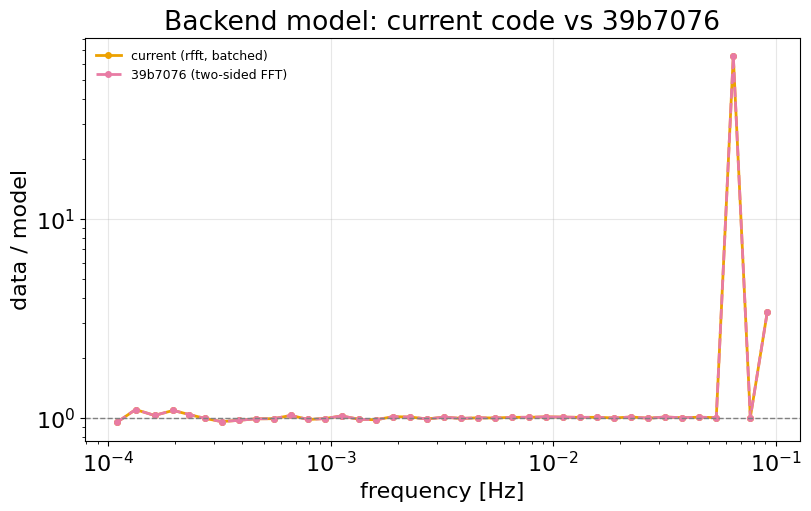

In [6]:
import ast, subprocess, textwrap

def methods_at(rev, names):
    """Extract XYZSensitivityBackend methods from sensitivity.py at a git revision."""
    src = subprocess.check_output(["git", "show", f"{rev}:src/lisatools/sensitivity.py"], text=True)
    cls = next(n for n in ast.walk(ast.parse(src)) if isinstance(n, ast.ClassDef) and n.name == "XYZSensitivityBackend")
    out = {}
    for node in cls.body:
        if isinstance(node, ast.FunctionDef) and node.name in names:
            is_setter = any(isinstance(d, ast.Attribute) and d.attr == "setter" for d in node.decorator_list)
            key = node.name + (".setter" if is_setter else "")
            ns = {"Optional": None, "np": np}
            exec(textwrap.dedent(ast.get_source_segment(src, node)), ns)
            out[key] = ns[node.name]
    return out

old = methods_at("39b70769", {"_get_window_kernel", "window_kernel", "_convolve_matrix_components"})

def convolve_39b7076(C, f, st, w):
    m = types.SimpleNamespace(xp=np, window_values=w, active_slice=st.active_slice,
                              basis_settings=types.SimpleNamespace(basis_shape_active=(1, f.size)))
    old["window_kernel.setter"](m, old["_get_window_kernel"](m))
    m.window_kernel_fft = m._window_kernel_fft          # the property the old code reads
    c = np.asarray(C, dtype=float)[None]
    z = np.zeros_like(c, dtype=complex)
    return old["_convolve_matrix_components"](m, c, c, c, z, z, z)[0][0]

M_new = models["backend: conv(S x filters)"]
M_old = convolve_39b7076(S_true(f) * resp, f, st, w)
print(f"max per-bin |M_39b7076 / M_current - 1| = {np.max(np.abs(M_old / M_new - 1)):.2e}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5), constrained_layout=True)
for name, M, col, ls in [("current (rfft, batched)", M_new, colors[1], "-"),
                         ("39b7076 (two-sided FFT)", M_old, "#e87ba4", "--")]:
    fc, r, s = binned(f, P / M, np.geomspace(f[0], f[-1], 40))
    ax.loglog(fc, r, ls, marker="o", color=col, lw=2, ms=4, label=name)
ax.axhline(1, color="0.5", lw=1, ls="--")
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("data / model")
ax.set_title("Backend model: current code vs 39b7076")
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=9)
plt.show()

## Optional: which preprocessing step causes a deviation?
Re-runs the chain with one step at a time (trim always on), each compared with its *own* full model (filters + aliases). Slower: one full preprocessing pass per row.

In [7]:
edges = np.geomspace(fmin, fmax, 10)
print(f"{'steps':>22s}" + "".join(f"{a:9.1e}" for a in edges[:-1]))
for steps in [["trim_kwargs"], ["highpass_kwargs", "trim_kwargs"], ["lowpass_kwargs", "trim_kwargs"],
              ["downsample_kwargs", "trim_kwargs"], list(preprocess_kwargs)]:
    fs_, Ps_, _, proc_, st_, w_ = periodogram(data, steps)
    r = Ps_ / backend_convolve(with_aliases(proc_, fs_), fs_, st_, w_)
    label = "+".join(s.split("_")[0] for s in steps)
    print(f"{label:>22s}" + "".join(f"{np.mean(r[(fs_ >= a) & (fs_ < b)]):9.3f}" for a, b in zip(edges[:-1], edges[1:])))

                 steps  1.0e-04  2.2e-04  4.6e-04  1.0e-03  2.2e-03  4.6e-03  1.0e-02  2.2e-02  4.6e-02
                  trim    1.043    0.979    0.996    0.994    0.998    1.003    1.001    1.001    1.000
         highpass+trim    1.043    0.979    0.996    0.994    0.998    1.003    1.001    1.001    1.000
          lowpass+trim    1.043    0.979    0.996    0.994    0.998    1.003    1.001    1.001    1.000
       downsample+trim    1.005    1.014    1.015    0.999    0.999    1.003    1.001    1.001    1.000
highpass+lowpass+downsample+trim    1.043    0.979    0.996    0.994    0.998    1.003    1.001    1.001    1.000
